In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip install -q datasets PyYAML

In [3]:
from pathlib import Path

import torch


PROJECT_ROOT = Path(
    "/content/drive/MyDrive/ATML/PA1"
)

REPO_ROOT = Path(
    "/content/drive/MyDrive/ATML/PA1-repo"
)

TASK2_WORK_ROOT = (
    PROJECT_ROOT / "task2"
)

TASK2_REPO_ROOT = (
    REPO_ROOT / "task2"
)

PACS_ROOT = (
    PROJECT_ROOT / "datasets/PACS"
)

CHECKPOINT_PATH = (
    TASK2_WORK_ROOT
    / "checkpoints/source_only_best.pt"
)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

if DEVICE.type != "cuda":
    raise RuntimeError(
        "Change the Colab runtime to GPU "
        "before training."
    )

print(
    "GPU:",
    torch.cuda.get_device_name(0),
)

Device: cuda
GPU: Tesla T4


In [4]:
%cd /content/drive/MyDrive/ATML/PA1-repo

import json
import yaml

import matplotlib.pyplot as plt
import pandas as pd
import torch

from datasets import load_from_disk

from common.seed import set_seed

from shared.pacs_loaders import (
    build_pacs_datasets,
    build_pacs_loaders,
)

from shared.pacs_protocol import (
    load_pacs_protocol,
)

from task2.evaluation.source_validation import (
    evaluate_source_domains,
)

from task2.models.backbone import (
    count_trainable_parameters,
)

from task2.models.classifier_head import (
    PACSClassifier,
)

from task2.selection.checkpointing import (
    SourceValidationSelector,
)

from task2.train import (
    train_task2_method,
)


SEED = 6304

set_seed(SEED)

with (
    TASK2_REPO_ROOT
    / "configs/base.yaml"
).open(
    "r",
    encoding="utf-8",
) as config_file:
    base_config = yaml.safe_load(
        config_file
    )

with (
    TASK2_REPO_ROOT
    / "configs/source_only.yaml"
).open(
    "r",
    encoding="utf-8",
) as config_file:
    method_config = yaml.safe_load(
        config_file
    )

print(
    "Method:",
    method_config[
        "method"
    ]["name"],
)

print(
    "Uses target images:",
    method_config[
        "method"
    ]["uses_unlabeled_target"],
)

print(
    "Selection metric:",
    base_config[
        "selection"
    ]["metric"],
)

/content/drive/.shortcut-targets-by-id/1tphHcVs5KfBbfa3Y2U6Gt0Lo7AWXysa4/ATML/PA1-repo
Method: source_only
Uses target images: False
Selection metric: mean_source_validation_macro_f1


In [5]:
pacs_dataset = load_from_disk(
    str(PACS_ROOT)
)

PACS_SPLIT_PATH = (
    REPO_ROOT
    / "shared/splits/"
    "pacs_sketch_seed6304.json"
)

pacs_protocol = load_pacs_protocol(
    PACS_SPLIT_PATH
)

print(
    "PACS images:",
    len(pacs_dataset),
)

print(
    "Source domains:",
    pacs_protocol[
        "source_domains"
    ],
)

print(
    "Target domain:",
    pacs_protocol[
        "target_domain"
    ],
)

PACS images: 9991
Source domains: ['photo', 'art_painting', 'cartoon']
Target domain: sketch


In [6]:
all_datasets = build_pacs_datasets(
    dataset=pacs_dataset,
    protocol=pacs_protocol,
)

all_loaders = build_pacs_loaders(
    datasets=all_datasets,
    source_batch_size=(
        base_config[
            "batching"
        ][
            "source_examples_per_domain"
        ]
    ),
    target_batch_size=(
        base_config[
            "batching"
        ]["target_batch_size"]
    ),
    evaluation_batch_size=(
        base_config[
            "batching"
        ][
            "evaluation_batch_size"
        ]
    ),
    number_of_workers=(
        base_config[
            "batching"
        ]["number_of_workers"]
    ),
    seed=SEED,
)

source_only_loaders = {
    "source_train": (
        all_loaders[
            "source_train"
        ]
    ),
    "source_validation": (
        all_loaders[
            "source_validation"
        ]
    ),
    "steps_per_epoch": (
        all_loaders[
            "steps_per_epoch"
        ]
    ),
}

print(
    "Steps per epoch:",
    source_only_loaders[
        "steps_per_epoch"
    ],
)

print(
    "Target loader available to trainer:",
    "target_adaptation"
    in source_only_loaders,
)

Steps per epoch: 234
Target loader available to trainer: False


In [7]:
set_seed(SEED)

model = PACSClassifier(
    number_of_classes=(
        base_config[
            "dataset"
        ][
            "number_of_classes"
        ]
    )
).to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=(
        base_config[
            "optimization"
        ]["learning_rate"]
    ),
    weight_decay=(
        base_config[
            "optimization"
        ]["weight_decay"]
    ),
)

selector = SourceValidationSelector(
    checkpoint_path=CHECKPOINT_PATH,
    patience=(
        base_config[
            "optimization"
        ][
            "early_stopping_patience"
        ]
    ),
)

print(
    "Trainable parameters:",
    count_trainable_parameters(
        model
    ),
)

print(
    "Checkpoint path:",
    CHECKPOINT_PATH,
)

print(
    "Maximum epochs:",
    base_config[
        "optimization"
    ]["maximum_epochs"],
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 164MB/s]


Trainable parameters: 11180103
Checkpoint path: /content/drive/MyDrive/ATML/PA1/task2/checkpoints/source_only_best.pt
Maximum epochs: 30


In [8]:
training_result = (
    train_task2_method(
        method_name="source_only",
        model=model,
        loaders=source_only_loaders,
        optimizer=optimizer,
        selector=selector,
        device=DEVICE,
        maximum_epochs=(
            base_config[
                "optimization"
            ]["maximum_epochs"]
        ),
        number_of_classes=(
            base_config[
                "dataset"
            ][
                "number_of_classes"
            ]
        ),
    )
)

model = training_result["model"]

training_history = (
    training_result["history"]
)

selected_checkpoint = (
    training_result[
        "selected_checkpoint"
    ]
)

history_path = (
    TASK2_REPO_ROOT
    / "results/"
    "source_only_training_history.csv"
)

history_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

training_history.to_csv(
    history_path,
    index=False,
)

print()
print(
    "Selected epoch:",
    selected_checkpoint["epoch"],
)

print(
    "Selected mean source macro-F1:",
    selected_checkpoint[
        "selection_score"
    ],
)

print(
    "History saved to:",
    history_path,
)

source_only epoch 1:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch 1: train loss=0.4918, mean validation macro-F1=0.8730, best=0.8730


source_only epoch 2:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch 2: train loss=0.2651, mean validation macro-F1=0.8884, best=0.8884


source_only epoch 3:   0%|          | 0/234 [00:00<?, ?it/s]

...

Epoch 15: train loss=0.0498, mean validation macro-F1=0.9201, best=0.9367


source_only epoch 16:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch 16: train loss=0.0499, mean validation macro-F1=0.9356, best=0.9367


source_only epoch 17:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch 17: train loss=0.0455, mean validation macro-F1=0.9303, best=0.9367
Early stopping triggered.

Selected epoch: 12
Selected mean source macro-F1: 0.9366743407680399
History saved to: /content/drive/MyDrive/ATML/PA1-repo/task2/results/source_only_training_history.csv


In [9]:
source_validation_results = (
    evaluate_source_domains(
        model=model,
        validation_loaders=(
            source_only_loaders[
                "source_validation"
            ]
        ),
        device=DEVICE,
        number_of_classes=7,
    )
)

source_result_rows = []

for domain_name, metrics in (
    source_validation_results[
        "domains"
    ].items()
):
    source_result_rows.append(
        {
            "method": "source_only",
            "domain": domain_name,
            "accuracy": (
                metrics["accuracy"]
            ),
            "macro_f1": (
                metrics["macro_f1"]
            ),
            "loss": metrics["loss"],
            "number_of_samples": (
                metrics[
                    "number_of_samples"
                ]
            ),
        }
    )

source_result_table = pd.DataFrame(
    source_result_rows
)

source_result_path = (
    TASK2_REPO_ROOT
    / "results/"
    "source_only_source_validation.csv"
)

source_result_table.to_csv(
    source_result_path,
    index=False,
)

print(
    source_result_table.to_string(
        index=False
    )
)

print()
print(
    "Mean source accuracy:",
    source_validation_results[
        "aggregate"
    ]["mean_accuracy"],
)

print(
    "Mean source macro-F1:",
    source_validation_results[
        "aggregate"
    ]["mean_macro_f1"],
)

print(
    "Worst source accuracy:",
    source_validation_results[
        "aggregate"
    ]["worst_accuracy"],
)

print(
    "Worst source macro-F1:",
    source_validation_results[
        "aggregate"
    ]["worst_macro_f1"],
)

     method       domain  accuracy  macro_f1     loss  number_of_samples
source_only        photo  0.961078  0.954999 0.097523                334
source_only art_painting  0.904878  0.898575 0.392316                410
source_only      cartoon  0.955224  0.956449 0.190924                469

Mean source accuracy: 0.9403932578962934
Mean source macro-F1: 0.9366743407680399
Worst source accuracy: 0.9048780487804878
Worst source macro-F1: 0.8985752686205901


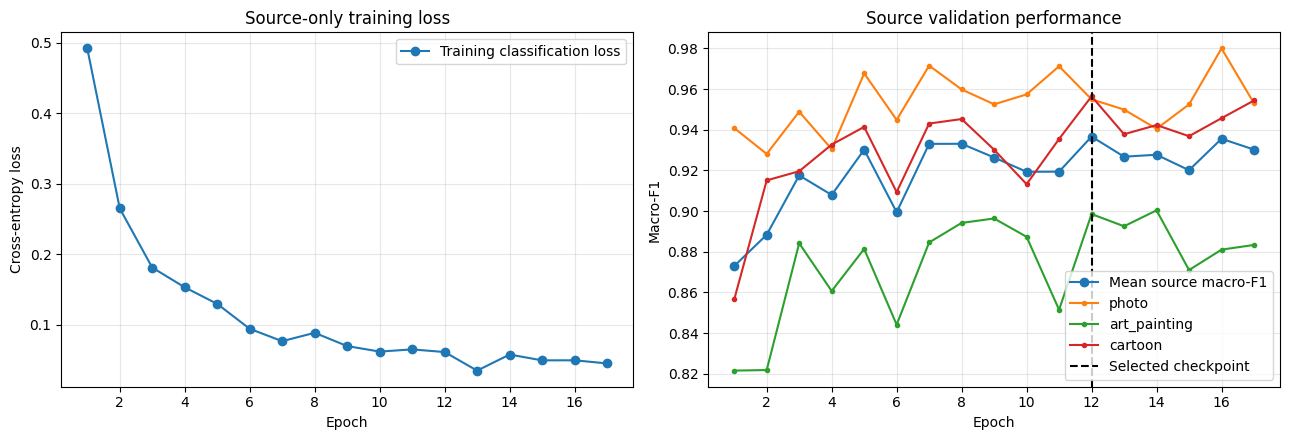

Figure saved to: /content/drive/MyDrive/ATML/PA1-repo/task2/figures/source_only_training_curves.png


In [10]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.5),
)

axes[0].plot(
    training_history["epoch"],
    training_history[
        "training_classification_loss"
    ],
    marker="o",
    label="Training classification loss",
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].set_title(
    "Source-only training loss"
)
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    training_history["epoch"],
    training_history[
        "mean_source_validation_macro_f1"
    ],
    marker="o",
    label="Mean source macro-F1",
)

for domain_name in [
    "photo",
    "art_painting",
    "cartoon",
]:
    axes[1].plot(
        training_history["epoch"],
        training_history[
            f"{domain_name}_validation_macro_f1"
        ],
        marker=".",
        label=domain_name,
    )

axes[1].axvline(
    selected_checkpoint["epoch"],
    color="black",
    linestyle="--",
    label="Selected checkpoint",
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro-F1")
axes[1].set_title(
    "Source validation performance"
)
axes[1].grid(alpha=0.3)
axes[1].legend()

figure.tight_layout()

figure_path = (
    TASK2_REPO_ROOT
    / "figures/"
    "source_only_training_curves.png"
)

figure_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

figure.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to:",
    figure_path,
)

In [11]:
import json


source_only_metadata = {
    "method": "source_only",
    "seed": SEED,
    "selected_epoch": int(
        selected_checkpoint["epoch"]
    ),
    "selection_metric": (
        selected_checkpoint[
            "selection_metric"
        ]
    ),
    "selection_score": float(
        selected_checkpoint[
            "selection_score"
        ]
    ),
    "checkpoint_filename": (
        CHECKPOINT_PATH.name
    ),
    "reused_as_task3_erm": True,
    "target_images_used_during_training": False,
    "target_labels_used": False,
    "source_validation": {
        domain_name: {
            "accuracy": float(
                metrics["accuracy"]
            ),
            "macro_f1": float(
                metrics["macro_f1"]
            ),
            "loss": float(
                metrics["loss"]
            ),
            "number_of_samples": int(
                metrics[
                    "number_of_samples"
                ]
            ),
        }
        for domain_name, metrics
        in source_validation_results[
            "domains"
        ].items()
    },
    "aggregate_source_validation": {
        key: float(value)
        for key, value
        in source_validation_results[
            "aggregate"
        ].items()
    },
}

metadata_path = (
    TASK2_REPO_ROOT
    / "results/"
    "source_only_metadata.json"
)

with metadata_path.open(
    "w",
    encoding="utf-8",
) as metadata_file:
    json.dump(
        source_only_metadata,
        metadata_file,
        indent=2,
    )

print(
    json.dumps(
        source_only_metadata,
        indent=2,
    )
)

{
  "method": "source_only",
  "seed": 6304,
  "selected_epoch": 12,
  "selection_metric": "mean_source_validation_macro_f1",
  "selection_score": 0.9366743407680399,
  "checkpoint_filename": "source_only_best.pt",
  "reused_as_task3_erm": true,
  "target_images_used_during_training": false,
  "target_labels_used": false,
  "source_validation": {
    "photo": {
      "accuracy": 0.9610778443113772,
      "macro_f1": 0.9549985174394315,
      "loss": 0.09752263708742792,
      "number_of_samples": 334
    },
    "art_painting": {
      "accuracy": 0.9048780487804878,
      "macro_f1": 0.8985752686205901,
      "loss": 0.39231610723384996,
      "number_of_samples": 410
    },
    "cartoon": {
      "accuracy": 0.9552238805970149,
      "macro_f1": 0.956449236244098,
      "loss": 0.19092371392605909,
      "number_of_samples": 469
    }
  },
  "aggregate_source_validation": {
    "mean_accuracy": 0.9403932578962934,
    "worst_accuracy": 0.9048780487804878,
    "mean_macro_f1": 0.936674